# TASK 3: TRỰC QUAN HÓA DỮ LIỆU (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("TASK 3: TRỰC QUAN HÓA DỮ LIỆU (EDA)")


TASK 3: TRỰC QUAN HÓA DỮ LIỆU (EDA)


## LOAD CLEANED DATA

In [2]:
print("\nLoading cleaned data...")
movies = pd.read_csv('../data/cleaned/movies_cleaned.csv')
ratings = pd.read_csv('../data/cleaned/ratings_cleaned.csv')
users = pd.read_csv('../data/cleaned/users_cleaned.csv')

print(f"Movies:  {len(movies):,} rows")
print(f"Ratings: {len(ratings):,} rows")
print(f"Users:   {len(users):,} rows")

# Create output folder
import os
os.makedirs('../figures', exist_ok=True)

# Initialize insights list
insights = []


Loading cleaned data...
Movies:  3,416 rows
Ratings: 1,000,209 rows
Users:   6,040 rows


## HISTOGRAM - PHÂN BỐ RATING

HISTOGRAM - PHÂN BỐ RATING


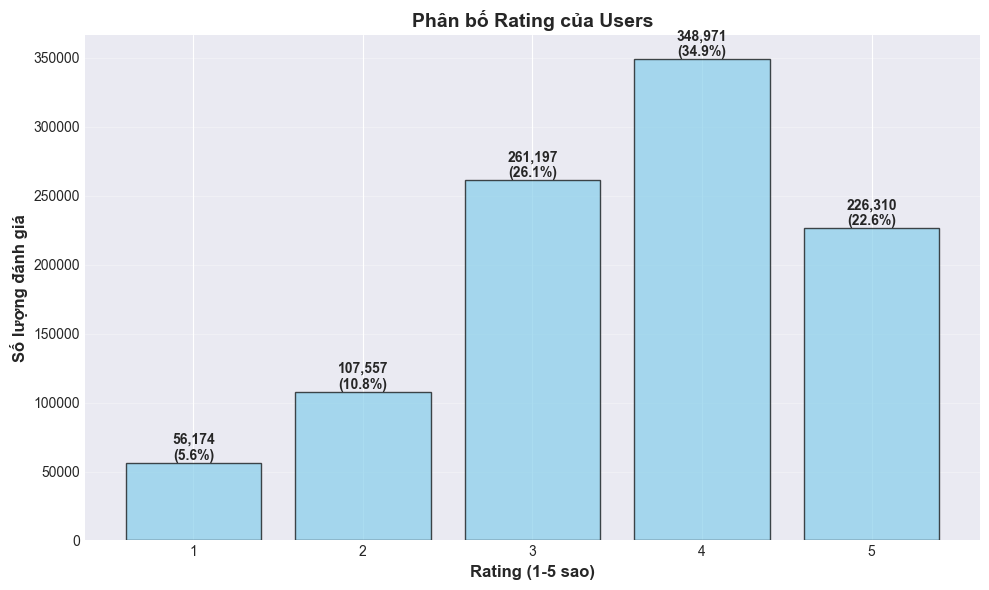

Đã lưu: figures/01_rating_distribution.png

VIZ 1: PHÂN BỐ RATING
Rating trung bình: 3.58
Rating trung vị: 4.0
Rating phổ biến nhất: 4.0
Độ lệch (skewness): -0.554

Phân bố: Lệch trái (negative)
Nhận xét: Users có xu hướng cho điểm cao.
Rating phổ biến nhất: 4 sao (348,971 lượt, 34.9%)

Insight: Positive bias - users thường rate phim họ thích



In [3]:
print("HISTOGRAM - PHÂN BỐ RATING")
plt.figure(figsize=(10, 6))
rating_counts = ratings['rating'].value_counts().sort_index()

# Plot histogram
plt.bar(rating_counts.index, rating_counts.values, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Rating (1-5 sao)', fontsize=12, fontweight='bold')
plt.ylabel('Số lượng đánh giá', fontsize=12, fontweight='bold')
plt.title('Phân bố Rating của Users', fontsize=14, fontweight='bold')
plt.xticks(range(1, 6))
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for rating, count in rating_counts.items():
    plt.text(rating, count, f'{count:,}\n({count/len(ratings)*100:.1f}%)', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/01_rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Đã lưu: figures/01_rating_distribution.png")

# Analysis
mean_rating = ratings['rating'].mean()
median_rating = ratings['rating'].median()
mode_rating = ratings['rating'].mode()[0]
skewness = ratings['rating'].skew()

insight_1 = f"""
VIZ 1: PHÂN BỐ RATING
Rating trung bình: {mean_rating:.2f}
Rating trung vị: {median_rating:.1f}
Rating phổ biến nhất: {mode_rating:.1f}
Độ lệch (skewness): {skewness:.3f}

Phân bố: {"Lệch trái (negative)" if skewness < 0 else "Lệch phải (positive)" if skewness > 0 else "Cân bằng"}
Nhận xét: Users có xu hướng {'cho điểm cao' if mean_rating > 3 else 'cho điểm thấp' if mean_rating < 3 else 'cho điểm trung bình'}.
Rating phổ biến nhất: {mode_rating} sao ({rating_counts[mode_rating]:,} lượt, {rating_counts[mode_rating]/len(ratings)*100:.1f}%)

Insight: {'Positive bias - users thường rate phim họ thích' if mean_rating > 3 else 'Users khá khắt khe' if mean_rating < 3 else 'Rating cân bằng'}
"""
insights.append(insight_1)
print(insight_1)

## BAR CHART - TOP GENRES

BAR CHART - TOP GENRES PHỔ BIẾN


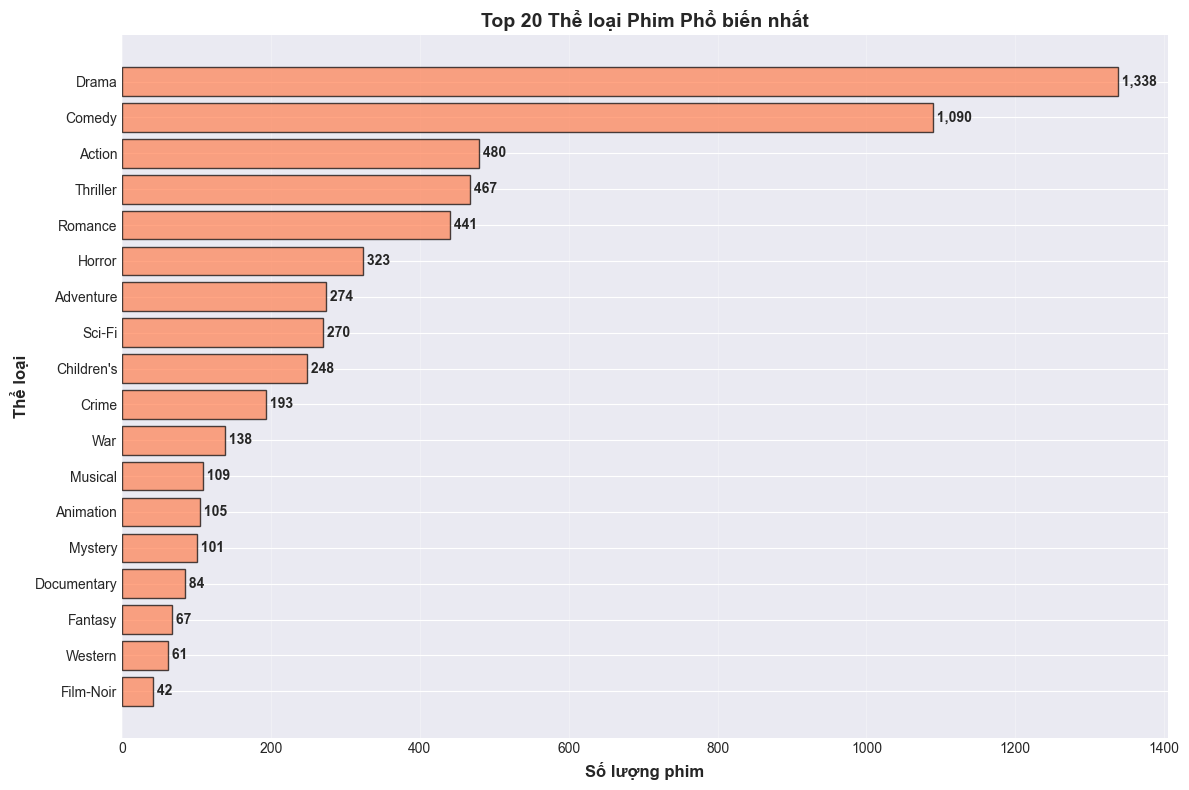

Đã lưu: figures/02_top_genres.png

VIZ 2: TOP GENRES
Tổng số thể loại: 18
Top 3 thể loại phổ biến:
  1. Drama: 1,338 phim (39.2%)
  2. Comedy: 1,090 phim (31.9%)
  3. Action: 480 phim (14.1%)

Insight: Drama là thể loại chiếm ưu thế trong dataset.
Sở thích của users nghiêng về Drama, Comedy, Action.



In [4]:
print("BAR CHART - TOP GENRES PHỔ BIẾN")

# Extract all genres
all_genres = []
for genres_str in movies['genres'].dropna():
    all_genres.extend(genres_str.split('|'))

genre_counts = pd.Series(all_genres).value_counts().head(20)

plt.figure(figsize=(12, 8))
plt.barh(range(len(genre_counts)), genre_counts.values, color='coral', edgecolor='black', alpha=0.7)
plt.yticks(range(len(genre_counts)), genre_counts.index)
plt.xlabel('Số lượng phim', fontsize=12, fontweight='bold')
plt.ylabel('Thể loại', fontsize=12, fontweight='bold')
plt.title('Top 20 Thể loại Phim Phổ biến nhất', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (genre, count) in enumerate(genre_counts.items()):
    plt.text(count, i, f' {count:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/02_top_genres.png', dpi=300, bbox_inches='tight')
plt.show()
print("Đã lưu: figures/02_top_genres.png")

# Analysis
top_3_genres = genre_counts.head(3)
insight_2 = f"""
VIZ 2: TOP GENRES
Tổng số thể loại: {len(genre_counts)}
Top 3 thể loại phổ biến:
  1. {top_3_genres.index[0]}: {top_3_genres.values[0]:,} phim ({top_3_genres.values[0]/len(movies)*100:.1f}%)
  2. {top_3_genres.index[1]}: {top_3_genres.values[1]:,} phim ({top_3_genres.values[1]/len(movies)*100:.1f}%)
  3. {top_3_genres.index[2]}: {top_3_genres.values[2]:,} phim ({top_3_genres.values[2]/len(movies)*100:.1f}%)

Insight: {top_3_genres.index[0]} là thể loại chiếm ưu thế trong dataset.
Sở thích của users nghiêng về {', '.join(top_3_genres.index[:3])}.
"""
insights.append(insight_2)
print(insight_2)


## HEATMAP - USER-MOVIE MATRIX (SPARSITY)

HEATMAP - MA TRẬN USER-MOVIE (SPARSITY)


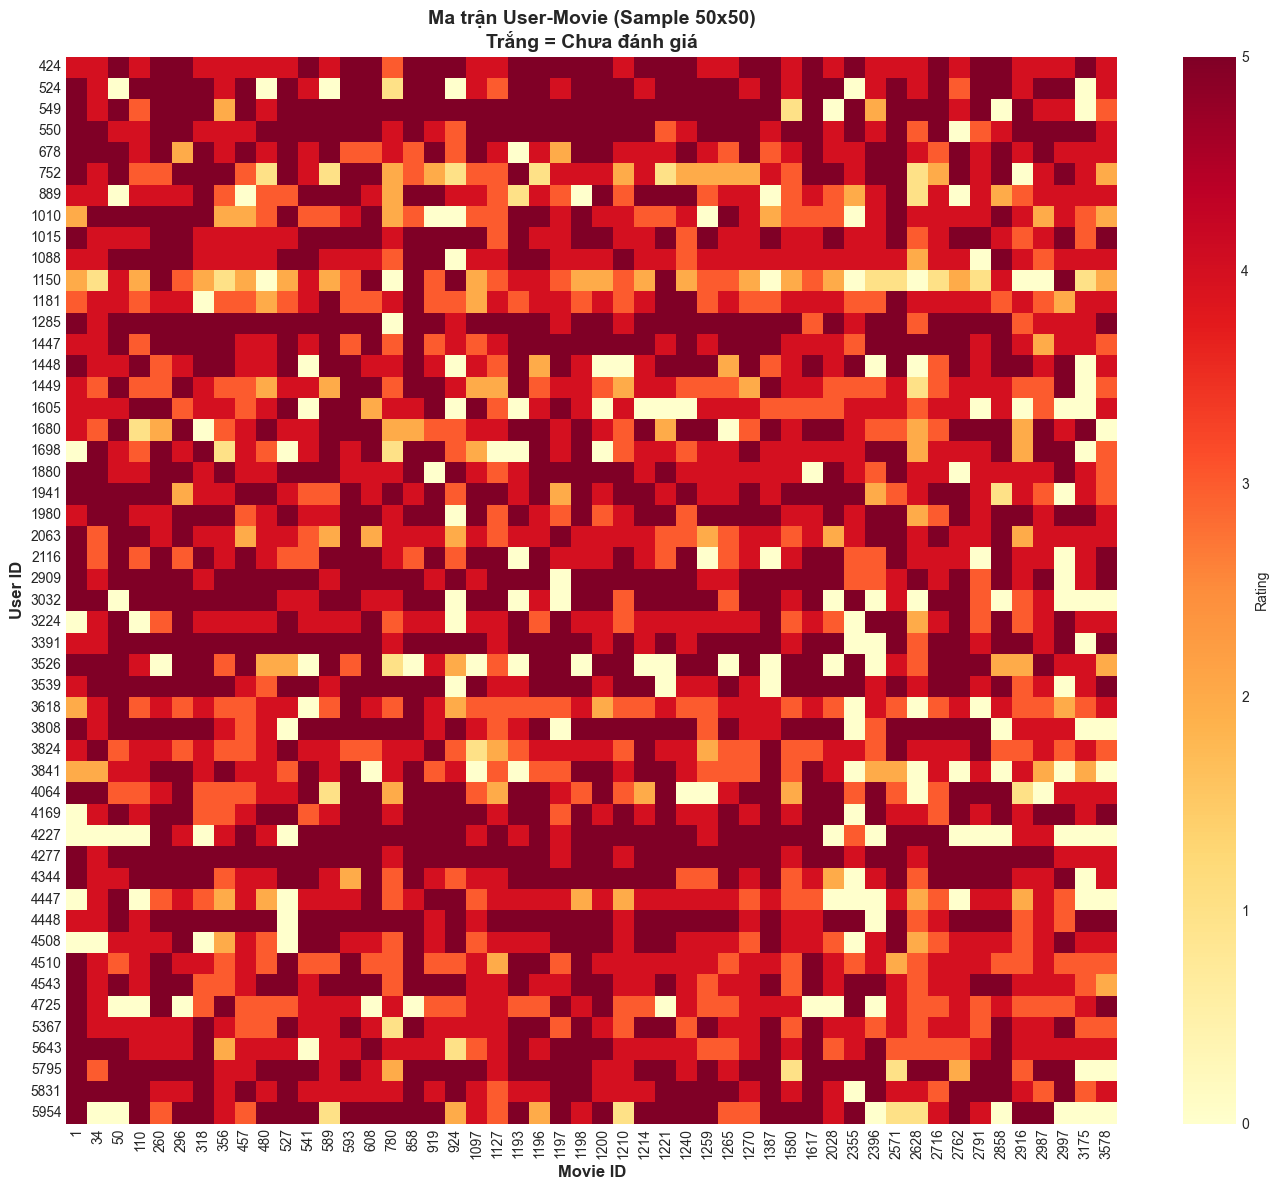

Đã lưu: figures/03_user_movie_heatmap.png

VIZ 3: ĐỘ THƯA CỦA MA TRẬN USER-MOVIE
Tổng số users: 6,040
Tổng số movies: 3,706
Tổng số rating có thể có: 22,384,240
Số rating thực tế: 1,000,209
Độ thưa (Sparsity): 95.53%

Insight: Ma trận rất thưa (95.5% ô trống).
Điều này rất phổ biến trong hệ thống gợi ý và chứng minh sự cần thiết của
Collaborative Filtering và Hybrid approaches.



In [5]:
print("HEATMAP - MA TRẬN USER-MOVIE (SPARSITY)")

# Sample 50 users and 50 movies
sample_users = ratings['userId'].value_counts().head(50).index
sample_movies = ratings['movieId'].value_counts().head(50).index

sample_ratings = ratings[
    (ratings['userId'].isin(sample_users)) & 
    (ratings['movieId'].isin(sample_movies))
]

# Create pivot table
matrix = sample_ratings.pivot_table(
    index='userId', 
    columns='movieId', 
    values='rating', 
    fill_value=0
)

plt.figure(figsize=(14, 12))
sns.heatmap(matrix, cmap='YlOrRd', cbar_kws={'label': 'Rating'}, 
            linewidths=0, square=False, vmin=0, vmax=5)
plt.xlabel('Movie ID', fontsize=12, fontweight='bold')
plt.ylabel('User ID', fontsize=12, fontweight='bold')
plt.title('Ma trận User-Movie (Sample 50x50)\nTrắng = Chưa đánh giá', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/03_user_movie_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Đã lưu: figures/03_user_movie_heatmap.png")

# Calculate sparsity
total_possible = len(ratings['userId'].unique()) * len(ratings['movieId'].unique())
actual_ratings = len(ratings)
sparsity = (1 - actual_ratings / total_possible) * 100

insight_3 = f"""
VIZ 3: ĐỘ THƯA CỦA MA TRẬN USER-MOVIE
Tổng số users: {len(ratings['userId'].unique()):,}
Tổng số movies: {len(ratings['movieId'].unique()):,}
Tổng số rating có thể có: {total_possible:,}
Số rating thực tế: {actual_ratings:,}
Độ thưa (Sparsity): {sparsity:.2f}%

Insight: Ma trận rất thưa ({sparsity:.1f}% ô trống).
Điều này rất phổ biến trong hệ thống gợi ý và chứng minh sự cần thiết của
Collaborative Filtering và Hybrid approaches.
"""
insights.append(insight_3)
print(insight_3)

## BAR CHART - TOP MOVIES

BAR CHART - TOP 20 PHIM ĐƯỢC ĐÁNH GIÁ NHIỀU NHẤT


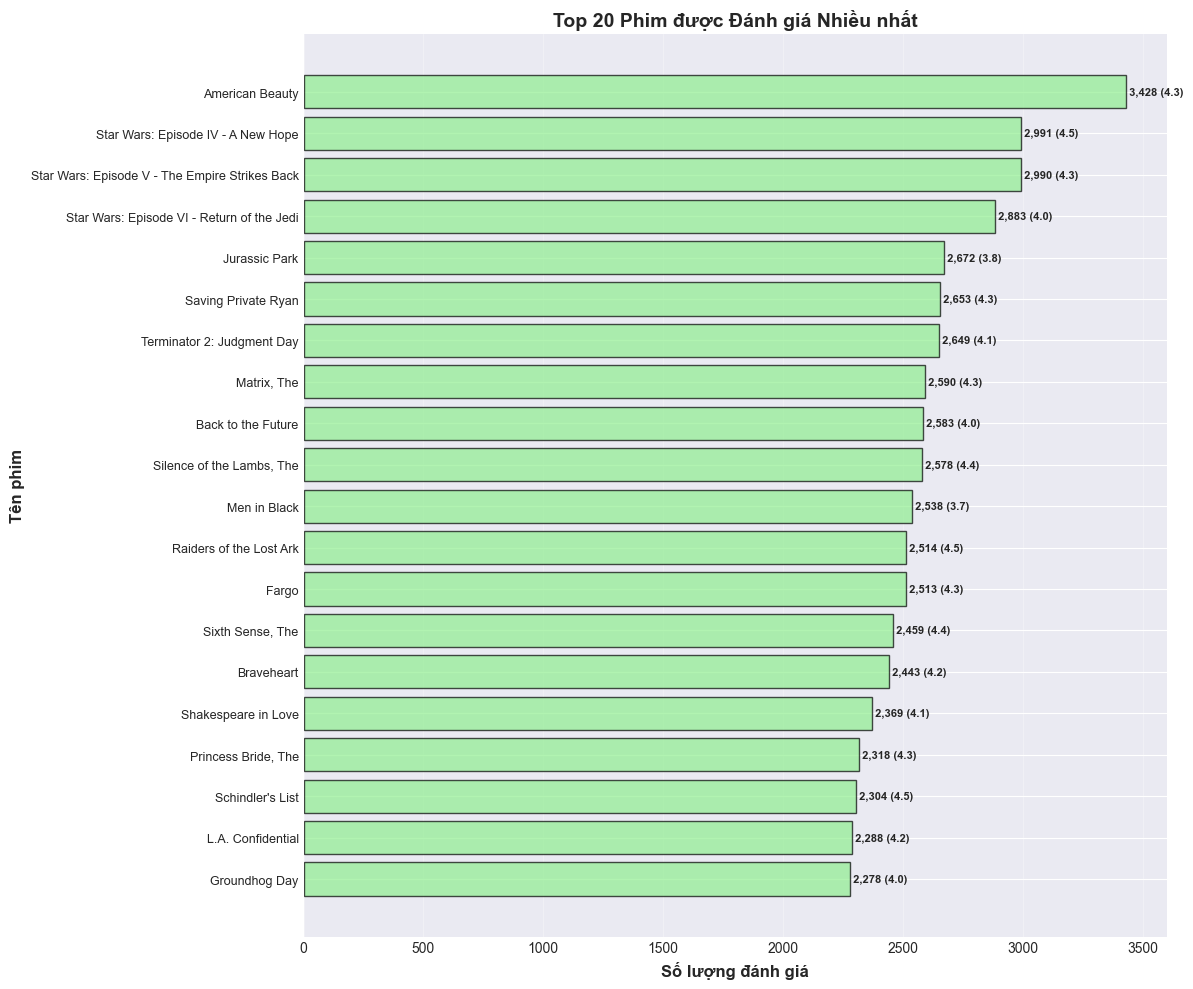

Đã lưu: figures/04_top_movies.png

VIZ 4: TOP PHIM ĐƯỢC ĐÁNH GIÁ NHIỀU
Phim được đánh giá nhiều nhất: American Beauty
  - Số lượng ratings: 3,428
  - Rating trung bình: 4.32/5.0
  - Thể loại: Comedy|Drama

Top 20 phim chiếm 52,041 ratings 
(5.2% tổng số ratings)

Insight: Các phim nổi tiếng chiếm ưu thế trong tương tác của users. 
Đây có thể là các bom tấn mà hầu hết users đã xem.



In [6]:
print("BAR CHART - TOP 20 PHIM ĐƯỢC ĐÁNH GIÁ NHIỀU NHẤT")

top_movies = movies.nlargest(20, 'rating_count')[['title_clean', 'rating_count', 'rating_avg', 'genres']]

plt.figure(figsize=(12, 10))
plt.barh(range(len(top_movies)), top_movies['rating_count'].values, 
         color='lightgreen', edgecolor='black', alpha=0.7)
plt.yticks(range(len(top_movies)), top_movies['title_clean'].values, fontsize=9)
plt.xlabel('Số lượng đánh giá', fontsize=12, fontweight='bold')
plt.ylabel('Tên phim', fontsize=12, fontweight='bold')
plt.title('Top 20 Phim được Đánh giá Nhiều nhất', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (title, count, avg) in enumerate(zip(top_movies['title_clean'], 
                                              top_movies['rating_count'], 
                                              top_movies['rating_avg'])):
    plt.text(count, i, f' {count:,} ({avg:.1f})', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/04_top_movies.png', dpi=300, bbox_inches='tight')
plt.show()
print("Đã lưu: figures/04_top_movies.png")

# Analysis
most_rated = top_movies.iloc[0]
insight_4 = f"""
VIZ 4: TOP PHIM ĐƯỢC ĐÁNH GIÁ NHIỀU
Phim được đánh giá nhiều nhất: {most_rated['title_clean']}
  - Số lượng ratings: {most_rated['rating_count']:,}
  - Rating trung bình: {most_rated['rating_avg']:.2f}/5.0
  - Thể loại: {most_rated['genres']}

Top 20 phim chiếm {top_movies['rating_count'].sum():,} ratings 
({top_movies['rating_count'].sum()/len(ratings)*100:.1f}% tổng số ratings)

Insight: Các phim nổi tiếng chiếm ưu thế trong tương tác của users. 
Đây có thể là các bom tấn mà hầu hết users đã xem.
"""
insights.append(insight_4)
print(insight_4)

## LINE CHART - RATINGS THEO THỜI GIAN

LINE CHART - RATINGS THEO THỜI GIAN


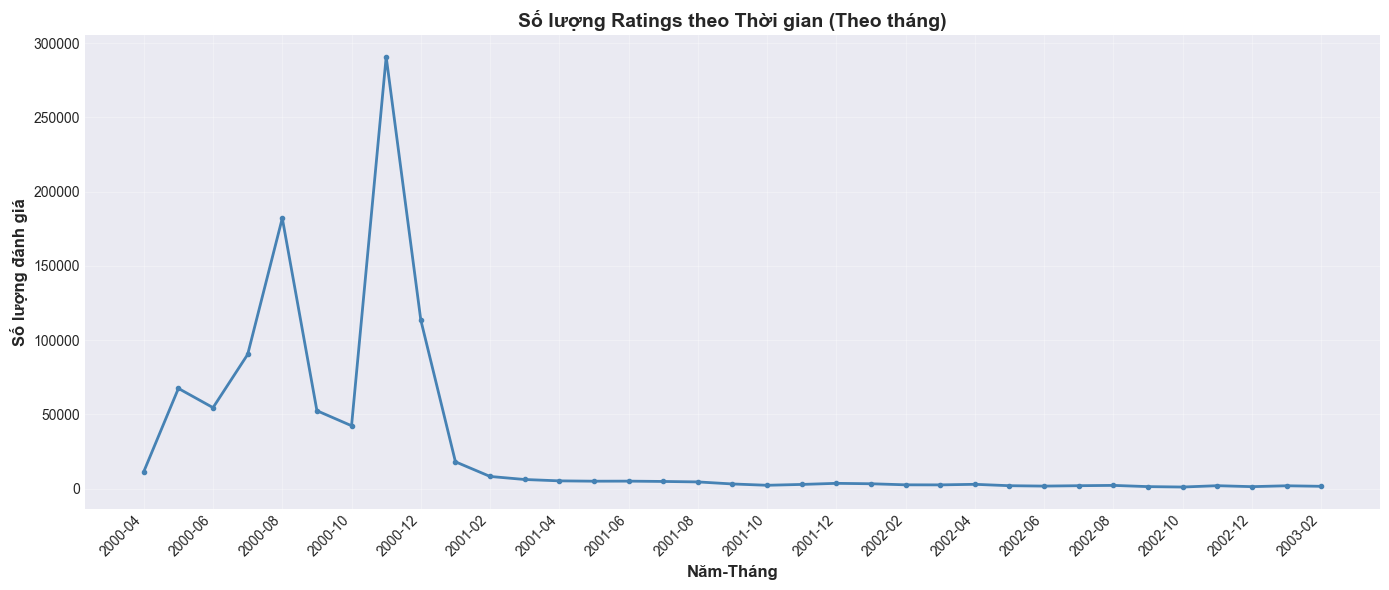

Đã lưu: figures/05_ratings_over_time.png

VIZ 5: RATINGS THEO THỜI GIAN
Khoảng thời gian: 2000-04 đến 2003-02
Tổng số tháng: 35
Tháng có nhiều ratings nhất: 2000-11 (290,793 ratings)
Trung bình ratings/tháng: 28,577

Insight: Xu hướng giảm trong hoạt động của users.
Hoạt động cao nhất vào 2000-11 cho thấy có thể có pattern theo mùa hoặc giai đoạn thu thập dữ liệu.



In [7]:
print("LINE CHART - RATINGS THEO THỜI GIAN")

# Convert timestamp to datetime
ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year_month'] = ratings['date'].dt.to_period('M')

# Count ratings per month
ratings_over_time = ratings.groupby('year_month').size()

plt.figure(figsize=(14, 6))
plt.plot(ratings_over_time.index.astype(str), ratings_over_time.values, 
         linewidth=2, color='steelblue', marker='o', markersize=3)
plt.xlabel('Năm-Tháng', fontsize=12, fontweight='bold')
plt.ylabel('Số lượng đánh giá', fontsize=12, fontweight='bold')
plt.title('Số lượng Ratings theo Thời gian (Theo tháng)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)

# Show only every Nth label to avoid overcrowding
n = len(ratings_over_time) // 20 + 1
plt.gca().set_xticks(plt.gca().get_xticks()[::n])

plt.tight_layout()
plt.savefig('../figures/05_ratings_over_time.png', dpi=300, bbox_inches='tight')
plt.show()
print("Đã lưu: figures/05_ratings_over_time.png")

# Analysis
peak_month = ratings_over_time.idxmax()
peak_count = ratings_over_time.max()
avg_monthly = ratings_over_time.mean()

insight_5 = f"""
VIZ 5: RATINGS THEO THỜI GIAN
Khoảng thời gian: {ratings_over_time.index.min()} đến {ratings_over_time.index.max()}
Tổng số tháng: {len(ratings_over_time)}
Tháng có nhiều ratings nhất: {peak_month} ({peak_count:,} ratings)
Trung bình ratings/tháng: {avg_monthly:,.0f}

Insight: {'Xu hướng tăng' if ratings_over_time.iloc[-1] > ratings_over_time.iloc[0] else 'Xu hướng giảm' if ratings_over_time.iloc[-1] < ratings_over_time.iloc[0] else 'Xu hướng ổn định'} trong hoạt động của users.
Hoạt động cao nhất vào {peak_month} cho thấy có thể có pattern theo mùa hoặc giai đoạn thu thập dữ liệu.
"""
insights.append(insight_5)
print(insight_5)

## RATING THEO GENRE

RATING TRUNG BÌNH THEO GENRE


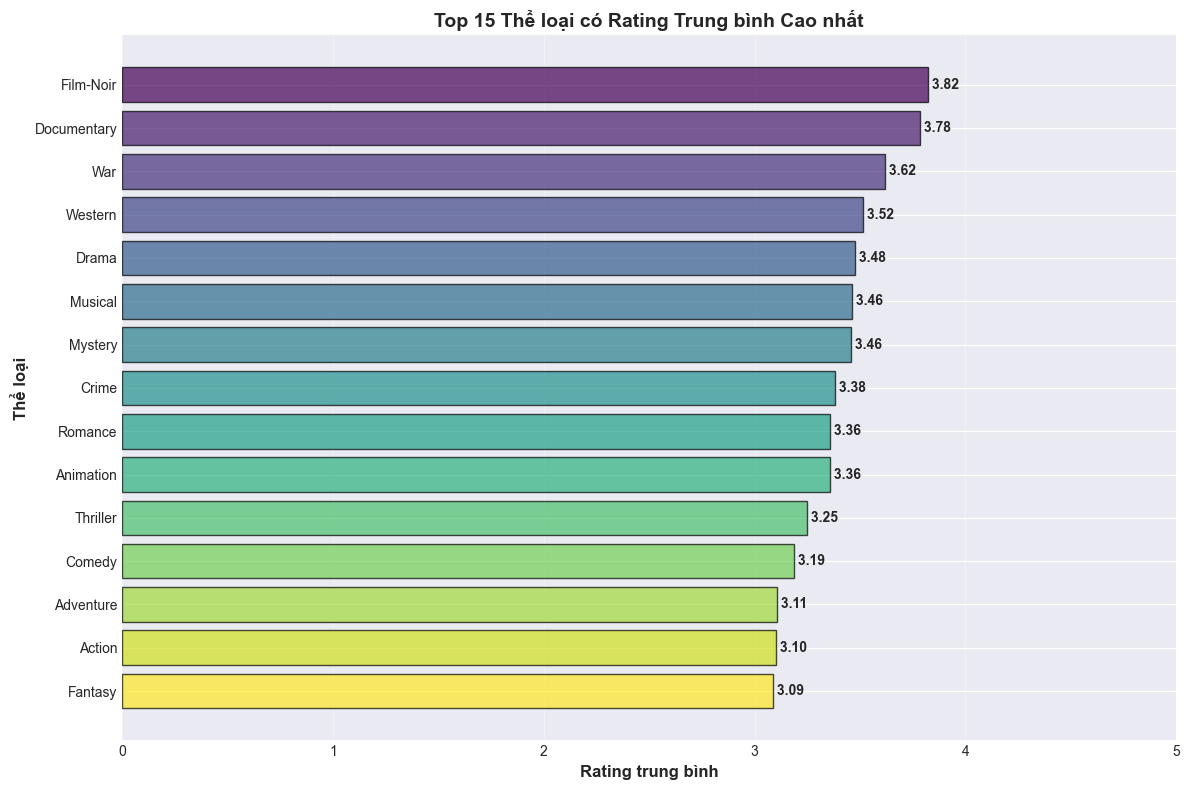

Đã lưu: figures/06_rating_by_genre.png

VIZ 6: RATING THEO GENRE
Thể loại có rating cao nhất: Film-Noir (3.82★)
Thể loại thấp nhất (trong top 15): Fantasy (3.09★)

Insight: Chất lượng các thể loại khác nhau. Phim Film-Noir có xu hướng 
nhận rating cao hơn, cho thấy sở thích mạnh của users hoặc chất lượng sản xuất tốt hơn.



In [8]:
print("RATING TRUNG BÌNH THEO GENRE")

# Extract genre and rating
genre_ratings = []
for _, row in movies.iterrows():
    if pd.notna(row['genres']):
        for genre in row['genres'].split('|'):
            genre_ratings.append({
                'genre': genre,
                'rating_avg': row['rating_avg'],
                'rating_count': row['rating_count']
            })

genre_df = pd.DataFrame(genre_ratings)
genre_stats = genre_df.groupby('genre').agg({
    'rating_avg': 'mean',
    'rating_count': 'sum'
}).sort_values('rating_avg', ascending=False).head(15)

plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(genre_stats)))
plt.barh(range(len(genre_stats)), genre_stats['rating_avg'].values, 
         color=colors, edgecolor='black', alpha=0.7)
plt.yticks(range(len(genre_stats)), genre_stats.index)
plt.xlabel('Rating trung bình', fontsize=12, fontweight='bold')
plt.ylabel('Thể loại', fontsize=12, fontweight='bold')
plt.title('Top 15 Thể loại có Rating Trung bình Cao nhất', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.xlim(0, 5)

# Add value labels
for i, (genre, avg) in enumerate(genre_stats['rating_avg'].items()):
    plt.text(avg, i, f' {avg:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/06_rating_by_genre.png', dpi=300, bbox_inches='tight')
plt.show()
print("Đã lưu: figures/06_rating_by_genre.png")

# Analysis
top_rated_genre = genre_stats.index[0]
insight_6 = f"""
VIZ 6: RATING THEO GENRE
Thể loại có rating cao nhất: {top_rated_genre} ({genre_stats['rating_avg'].iloc[0]:.2f}★)
Thể loại thấp nhất (trong top 15): {genre_stats.index[-1]} ({genre_stats['rating_avg'].iloc[-1]:.2f}★)

Insight: Chất lượng các thể loại khác nhau. Phim {top_rated_genre} có xu hướng 
nhận rating cao hơn, cho thấy sở thích mạnh của users hoặc chất lượng sản xuất tốt hơn.
"""
insights.append(insight_6)
print(insight_6)

## LƯU INSIGHTS VÀO FILE

In [9]:
print("ĐANG LƯU INSIGHTS...")

insights_text = "\n".join(insights)
insights_header = f"""
PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) - TÓM TẮT INSIGHTS
Thời gian tạo: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

Thống kê Dataset:
- Số phim: {len(movies):,}
- Số đánh giá: {len(ratings):,}
- Số users: {len(users):,}
- Độ thưa: {sparsity:.2f}%

"""

full_insights = insights_header + insights_text

with open('../figures/EDA_insights.txt', 'w', encoding='utf-8') as f:
    f.write(full_insights)

print("Đã lưu: figures/EDA_insights.txt")

ĐANG LƯU INSIGHTS...
Đã lưu: figures/EDA_insights.txt


## TỔNG KẾT

In [10]:
print("TASK 3 HOÀN THÀNH!")

print("\nChecklist:")
print("Viz 1: Phân bố Rating (Histogram)")
print("Viz 2: Top Genres (Bar Chart)")
print("Viz 3: Ma trận User-Movie (Heatmap)")
print("Viz 4: Top Movies (Bar Chart)")
print("Viz 5: Ratings theo Thời gian (Line Chart)")
print("Viz 6: Rating theo Genre (Bar Chart) - BONUS")


print("\nOutput files:")
print("  - figures/01_rating_distribution.png")
print("  - figures/02_top_genres.png")
print("  - figures/03_user_movie_heatmap.png")
print("  - figures/04_top_movies.png")
print("  - figures/05_ratings_over_time.png")
print("  - figures/06_rating_by_genre.png")
print("  - figures/EDA_insights.txt")

print("\nInsights chính:")
print(f"Rating trung bình: {mean_rating:.2f} (positive bias)")
print(f"Thể loại phổ biến nhất: {top_3_genres.index[0]}")
print(f"Độ thưa ma trận: {sparsity:.1f}%")
print(f"Phim được rate nhiều nhất: {most_rated['title_clean']}")
print(f"Tháng hoạt động cao nhất: {peak_month}")

TASK 3 HOÀN THÀNH!

Checklist:
Viz 1: Phân bố Rating (Histogram)
Viz 2: Top Genres (Bar Chart)
Viz 3: Ma trận User-Movie (Heatmap)
Viz 4: Top Movies (Bar Chart)
Viz 5: Ratings theo Thời gian (Line Chart)
Viz 6: Rating theo Genre (Bar Chart) - BONUS

Output files:
  - figures/01_rating_distribution.png
  - figures/02_top_genres.png
  - figures/03_user_movie_heatmap.png
  - figures/04_top_movies.png
  - figures/05_ratings_over_time.png
  - figures/06_rating_by_genre.png
  - figures/EDA_insights.txt

Insights chính:
Rating trung bình: 3.58 (positive bias)
Thể loại phổ biến nhất: Drama
Độ thưa ma trận: 95.5%
Phim được rate nhiều nhất: American Beauty
Tháng hoạt động cao nhất: 2000-11
